## Module 3: Machine Learning for Classification

This module covers the fundamentals of **classification**, with a focus on predicting categorical outcomes from data. It introduces the typical classification workflow, including data preparation, feature analysis, model training, and evaluation. The main model used is **logistic regression**, along with techniques for handling categorical variables and interpreting model performance using metrics such as accuracy.

### Part 1: Data Preparation

In [1]:
# get telecom churn data
!wget 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv' -O data-week-3.csv

--2026-09-22 13:10:50--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.009s  

2026-09-22 13:10:51 (105 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [2]:
# load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# check the data
df = pd.read_csv('data-week-3.csv')
# since columns are too many and hidden, use transpose
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [3]:
# rewrite column names lowercase with no space (to be able to use in dot form)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# check categorical columns and make their content lowercase with no space
cat_cols = list(df.dtypes[df.dtypes == 'str'].index)
for col in cat_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [4]:
# check data types to clean the data 
# (totalcharges should be numeric but str, churn should be 1 or 0)
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [5]:
# turn column into numeric and ignore errors ('_' ones), fill missing with 0 (although not the best option)
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce').fillna(0)

# turn column into numeric rather than yes or no
df.churn = (df.churn == 'yes').astype(int)

### Part 2: Setting Up the Validation Framework

In [6]:
from sklearn.model_selection import train_test_split

# split data with sckit-learn (since sckitlearn func divides 2, do 2 times)
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1) # 1/5
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1) # 1/4 of remaining 4/5

# reset index for each
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# separate target variable
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

# delete target variable data from features
del df_train['churn']
del df_val['churn']
del df_test['churn']

# get the size of each set
print("Total size:", len(df))
print(f"Train, Val, Test: ({len(df_train)}, {len(df_val)}, {len(df_test)})")
print(f"y_train, y_val, y_test: ({len(y_train)}, {len(y_val)}, {len(y_test)})")

Total size: 7043
Train, Val, Test: (4225, 1409, 1409)
y_train, y_val, y_test: (4225, 1409, 1409)


### Part 3: Exploratory Data Analysis (EDA)

In [7]:
# use data except test one, check for null values
df_full_train = df_full_train.reset_index(drop=True)
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [8]:
# check mean and distribution of target variable
print('Mean churn (churn rate of customers):', df_full_train.churn.mean())
df_full_train.churn.value_counts(normalize=True)

Mean churn (churn rate of customers): 0.26996805111821087


churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [9]:
# separate numerical and categorical columns
numerical = ['tenure', 'monthlycharges', 'totalcharges']
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

# check number of unique values for all categorical columns
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### Part 4: Feature Importance - Churn Rate and Risk Ratio
#### Churn Rate:

In [10]:
# check columns again
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [11]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
global_churn = df_full_train.churn.mean()

print(f"Female churn rate: {churn_female * 100:.2f}%")
print(f"Male churn rate: {churn_male * 100:.2f}%")
print(f"Global churn rate: {global_churn * 100:.2f}%")
print(f"Global - Female: {(global_churn - churn_female) * 100:.2f}%")
print(f"Global - Male: {(global_churn - churn_male) * 100:.2f}%")

Female churn rate: 27.68%
Male churn rate: 26.32%
Global churn rate: 27.00%
Global - Female: -0.69%
Global - Male: 0.68%


In [12]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()

print(f"With partner rate: {churn_partner * 100:.2f}%")
print(f"With NO partner rate: {churn_no_partner * 100:.2f}%")
print(f"Global - with partner: {(global_churn - churn_partner) * 100:.2f}%")
print(f"Global - with NO partner: {(global_churn - churn_no_partner) * 100:.2f}%")

df_full_train.partner.value_counts()

With partner rate: 20.50%
With NO partner rate: 32.98%
Global - with partner: 6.49%
Global - with NO partner: -5.98%


partner
no     2932
yes    2702
Name: count, dtype: int64

Compare each group’s churn rate with the global churn rate:

* `diff > 0` / `diff < 0` → tells whether the group churns above or below average
* `|diff|` → tells how far the group is from the global rate
* Larger `|diff|` → stronger relationship with churn

Gender has very small absolute differences (~0.007), while partner status has much larger ones (~0.06). So partner status appears more informative for churn than gender.

#### Risk Ratio:

Risk ratio compares a group’s churn rate with the global churn rate:

* `risk > 1` → group churns more than average
* `risk < 1` → group churns less than average
* Farther from `1` → stronger relationship with churn

A risk ratio close to `1` means the group behaves similarly to the overall population.


In [13]:
print(f"churn_no_partner / global_churn: {churn_no_partner / global_churn}")
print(f"churn_partner / global_churn: {churn_partner / global_churn}")

churn_no_partner / global_churn: 1.2216593879412643
churn_partner / global_churn: 0.7594724924338315


```sql
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;
```

If does not show output below, use `from IPython.display import display`

In [14]:
# get above sql in pd
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


### Part 5: Feature Importance - Mutual Information

It is the concept from information theory, which tells us how much we can learn about one variable if we know the value of another.
In this example, we look for how much we learn about churn, when we know contract, gender and partner.

https://en.wikipedia.org/wiki/Mutual_information

In [15]:
from sklearn.metrics import mutual_info_score

# check mutual info score (direction does not matter)
print(f"contract vs churn: {mutual_info_score(df_full_train.contract, df_full_train.churn)}")
print(f"contract vs partner: {mutual_info_score(df_full_train.partner, df_full_train.churn)}")
print(f"contract vs gender: {mutual_info_score(df_full_train.gender, df_full_train.churn)}")

contract vs churn: 0.0983203874041556
contract vs partner: 0.009967689095399745
contract vs gender: 0.0001174846211139946


In [16]:
# check for multiple columns
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

# get and sort by their importance
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Part 6: Feature Importance - Correlation

For **numerical features**, we can use the **Pearson correlation coefficient (`r`)** to measure how strongly they are related to churn.

* `r > 0` → as the feature increases, churn tends to increase
* `r < 0` → as the feature increases, churn tends to decrease
* `r ≈ 0` → little or no linear relationship
* Larger `|r|` → stronger relationship / more important feature

A rough interpretation:

* `|r| < 0.2` → low
* `0.2 ≤ |r| < 0.5` → medium
* `|r| ≥ 0.5` → strong

In this dataset, **tenure has the strongest correlation with churn (`r ≈ -0.35`)**: customers who stay longer are less likely to churn. `monthlycharges` has a positive correlation, meaning higher monthly payments are associated with higher churn.

```python
df_full_train[numerical].corrwith(df_full_train.churn)
```

For feature importance, we usually compare the **absolute correlations**:

```python
df_full_train[numerical].corrwith(df_full_train.churn).abs()
```

In [17]:
print(f"Max tenure: {df_full_train.tenure.max()}")
print(f"Churn rate - stay <= 2 months: {df_full_train[df_full_train.tenure <= 2].churn.mean()}")
print(f"Churn rate - 2 months < stay <= 12 months: {df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()}")
print(f"Churn rate - stay > 12 months: {df_full_train[df_full_train.tenure > 12].churn.mean()}")

print(f"\nChurn rate - monthly charges <= 20$ : {df_full_train[df_full_train.monthlycharges <= 20].churn.mean()}")
print(f"Churn rate - 20$ < monthly charges <= 50$: {df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()}")
print(f"Churn rate - monthly charges > 50$: {df_full_train[df_full_train.monthlycharges > 50].churn.mean()}")

# absolute correlation rates for numeric columns
df_full_train[numerical].corrwith(df_full_train.churn).abs()

Max tenure: 72
Churn rate - stay <= 2 months: 0.5953420669577875
Churn rate - 2 months < stay <= 12 months: 0.3994413407821229
Churn rate - stay > 12 months: 0.17634908339788277

Churn rate - monthly charges <= 20$ : 0.08795411089866156
Churn rate - 20$ < monthly charges <= 50$: 0.18340943683409436
Churn rate - monthly charges > 50$: 0.32499341585462205


tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

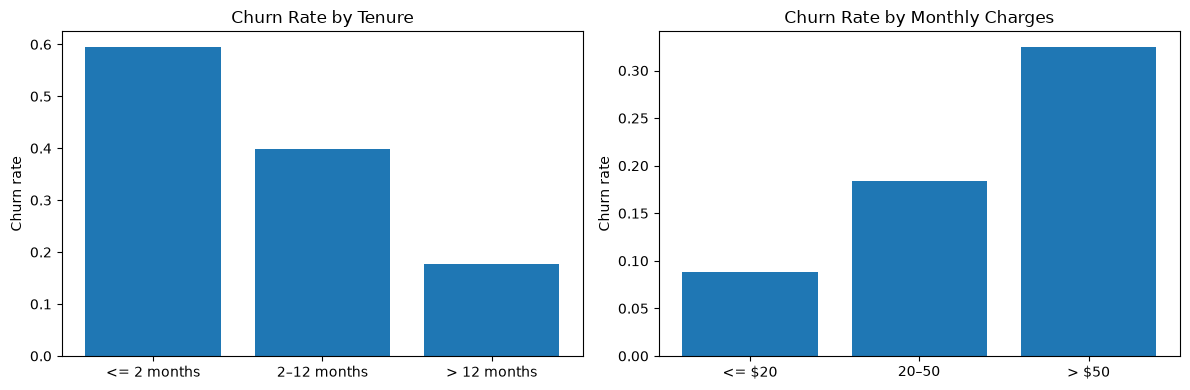

In [18]:
# churn rates by tenure group
tenure_rates = {
    "<= 2 months": df_full_train[df_full_train.tenure <= 2].churn.mean(),
    "2–12 months": df_full_train[
        (df_full_train.tenure > 2) & (df_full_train.tenure <= 12)
    ].churn.mean(),
    "> 12 months": df_full_train[df_full_train.tenure > 12].churn.mean()
}

# churn rates by monthly charge group
charge_rates = {
    "<= $20": df_full_train[df_full_train.monthlycharges <= 20].churn.mean(),
    "$20–$50": df_full_train[
        (df_full_train.monthlycharges > 20) &
        (df_full_train.monthlycharges <= 50)
    ].churn.mean(),
    "> $50": df_full_train[df_full_train.monthlycharges > 50].churn.mean()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(tenure_rates.keys(), tenure_rates.values())
axes[0].set_title("Churn Rate by Tenure")
axes[0].set_ylabel("Churn rate")

axes[1].bar(charge_rates.keys(), charge_rates.values())
axes[1].set_title("Churn Rate by Monthly Charges")
axes[1].set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

### Part 7: One-hot Encoding

In [19]:
# to get any one-hot encoded categorical data column, use library rather than manual as in module 2
# NOT (df_train.number_of_doors == 3).astype('int')
from sklearn.feature_extraction import DictVectorizer

# create a dict vectorizer (do not use sparse matrices)
dv = DictVectorizer(sparse=False)

In [20]:
# fit data to vectorizer and transform into one-hot-encoded (dict vectorizer does this only for categorical data)
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

# check features after one-hot encoding
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

`DictVectorizer` is still a valid and supported way to one-hot encode dictionary-based data. For pandas DataFrames, newer sklearn workflows often use `OneHotEncoder` together with `ColumnTransformer`, especially when building preprocessing pipelines. Here, `DictVectorizer` is kept because it is simpler and sufficient for this module.

### Part 8: Logistic Regression

Logistic regression is used for **classification**, especially binary classification where the target is `0` or `1`.

Like linear regression, it starts with a weighted sum of the features:

```text
z = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ
```

Instead of returning this value directly, logistic regression passes it through the **sigmoid function**:

```text
sigmoid(z) = 1 / (1 + exp(-z))
```

The sigmoid converts the score into a value between `0` and `1`, which can be interpreted as the **probability of belonging to the positive class**.

So the main difference is:

* Linear regression → predicts a continuous number
* Logistic regression → predicts a probability between `0` and `1`


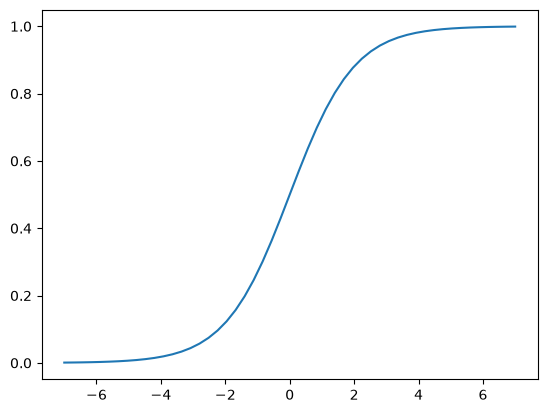

In [21]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-7, 7, 51)
# sigmoid(10000) == 1

plt.plot(z, sigmoid(z))

In [22]:
# linear regression formula from module 2
def linear_regression(x_i):
    """
    Predicts the target value for one observation using linear regression.

    The prediction is calculated as:
        prediction = w_0 + w[0]*x_i[0] + ... + w[n-1]*x_i[n-1]

    Parameters:
        x_i (list): Feature values for one observation.

    Returns:
        float: Predicted target value.
    """
    n = len(x_i)
    pred = w_0
    for j in range(n):
        pred += w[j] * x_i[j]

    return pred

In [23]:
# logistic regression formula from module 3
def logistic_regression(x_i):
    """
    Predicts the probability of the positive class for one observation
    using logistic regression.

    The prediction is calculated as:
        score = w_0 + w[0]*x_i[0] + ... + w[n-1]*x_i[n-1]
        prediction = sigmoid(score)

    Parameters:
        x_i (list): Feature values for one observation.

    Returns:
        float: Predicted probability between 0 and 1.
    """
    n = len(x_i)
    score = w_0

    for j in range(n):
        score += w[j] * x_i[j]

    prediction = sigmoid(score)
    return prediction

### Part 9: Training Logistic Regression with Scikit-Learn

In [24]:
# train logistic regression model
from sklearn.linear_model import LogisticRegression

# lbfgs is the default solver
# max_iter is increased because the default 100 iterations
# may not be enough for the model to converge
model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000 # needed to increase compared to the lecture
)

# fit trains the model from scratch
model.fit(X_train, y_train)

print(f"Bias / intercept (w_0): {model.intercept_[0]}")
print(f"Feature coefficients (w: weights) (rounded to 3 decimals):\n {model.coef_[0].round(3)}")
print(f"Number of training iterations: {model.n_iter_[0]}")

Bias / intercept (w_0): -0.04544302938501822
Feature coefficients (w: weights) (rounded to 3 decimals):
 [ 0.686  0.032 -0.678  0.055 -0.015  0.113 -0.16   0.087  0.039  0.001
 -0.498  0.698 -0.16  -0.018 -0.188  0.068  0.159  0.117 -0.16   0.083
  0.284 -0.16  -0.085 -0.161  0.201 -0.044  0.084 -0.053 -0.002  0.107
 -0.011  0.068 -0.028  0.195 -0.095 -0.16   0.295 -0.055 -0.16   0.255
  0.234 -0.16  -0.034 -0.068  0.   ]
Number of training iterations: 2572


In [25]:
# predicted class: 0 = not churn, 1 = churn
y_pred_class = model.predict(X_val)

print("Predicted classes:")
print(y_pred_class[:10])

# predicted probabilities
y_pred_proba = model.predict_proba(X_val)

print("\nProbability columns:")
print(model.classes_)   # usually [0, 1]

print("\nFirst 10 probability predictions:")
print(y_pred_proba[:10])

# probability of churn = 1
y_pred = y_pred_proba[:, 1]
print("\nFirst 10 probability of churn predictions:")
print(y_pred[:10])


Predicted classes:
[0 0 0 1 0 0 0 0 1 0]

Probability columns:
[0 1]

First 10 probability predictions:
[[0.99333409 0.00666591]
 [0.7951737  0.2048263 ]
 [0.78229605 0.21770395]
 [0.43624616 0.56375384]
 [0.78158144 0.21841856]
 [0.76939209 0.23060791]
 [0.96588658 0.03411342]
 [0.99809091 0.00190909]
 [0.40481719 0.59518281]
 [0.53516864 0.46483136]]

First 10 probability of churn predictions:
[0.00666591 0.2048263  0.21770395 0.56375384 0.21841856 0.23060791
 0.03411342 0.00190909 0.59518281 0.46483136]


In [26]:
# classify customers as churn if predicted probability is at least 50%
churn_decision = (y_pred >= 0.5)

# calculate how often the predicted churn decision matches the actual value
accuracy = (y_val == churn_decision).mean()

print(f"Prediction accuracy: {accuracy:.3f}")
print(f"Percentage of correct predictions: {accuracy:.1%}")

Prediction accuracy: 0.803
Percentage of correct predictions: 80.3%


In [27]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred.prediction == df_pred.actual
print(f"Percentage of correct predictions: {df_pred.correct.mean():.1%}")

df_pred.head(5)

Percentage of correct predictions: 80.3%


,probability,prediction,actual,correct
0,0.006666,0,0,True
1,0.204826,0,0,True
2,0.217704,0,0,True
3,0.563754,1,1,True
4,0.218419,0,0,True


### Part 10: Model Interpretation

Logistic regression learns a **bias** \(w_0\) and one **weight** for each encoded feature.

To understand the model, pair the feature names with their learned weights:

```python
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))
```

Interpretation:

* **Positive weight** → pushes the prediction toward higher churn probability
* **Negative weight** → pushes the prediction toward lower churn probability
* Larger absolute weight → stronger effect on the model score

For one-hot encoded categorical features, only the active category contributes. For example, if `contract=two_year` is `1`, the other contract categories are `0`.

The model first calculates:

```text
score = w_0 + w_1*x_1 + ... + w_n*x_n
```

and then applies the sigmoid:

```text
probability = sigmoid(score)
```

So:

* positive score → probability above `0.5`
* negative score → probability below `0.5`
* score near `0` → probability near `0.5`

A smaller model with only a few important features can make these relationships easier to interpret.

In [28]:
# check the values for each weights corresponding to related feature
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.686),
 'contract=one_year': np.float64(0.032),
 'contract=two_year': np.float64(-0.678),
 'dependents=no': np.float64(0.055),
 'dependents=yes': np.float64(-0.015),
 'deviceprotection=no': np.float64(0.113),
 'deviceprotection=no_internet_service': np.float64(-0.16),
 'deviceprotection=yes': np.float64(0.087),
 'gender=female': np.float64(0.039),
 'gender=male': np.float64(0.001),
 'internetservice=dsl': np.float64(-0.498),
 'internetservice=fiber_optic': np.float64(0.698),
 'internetservice=no': np.float64(-0.16),
 'monthlycharges': np.float64(-0.018),
 'multiplelines=no': np.float64(-0.188),
 'multiplelines=no_phone_service': np.float64(0.068),
 'multiplelines=yes': np.float64(0.159),
 'onlinebackup=no': np.float64(0.117),
 'onlinebackup=no_internet_service': np.float64(-0.16),
 'onlinebackup=yes': np.float64(0.083),
 'onlinesecurity=no': np.float64(0.284),
 'onlinesecurity=no_internet_service': np.float64(-0.16),
 'onlinesecurity=yes': np.flo

In [29]:
# train a smaller logistic regression model to make interpretation easier
small = ['contract', 'tenure', 'monthlycharges']

# check filtering
# df_train[small].iloc[:10].to_dict(orient='records')

# convert the selected features into dictionaries for DictVectorizer
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

# one-hot encode categorical features and keep numerical features unchanged
dv_small = DictVectorizer(sparse=False)

# could be separated but together is more practical
X_train_small = dv_small.fit_transform(dicts_train_small)
# reuse the encoding learned from the training set for validation
X_val_small = dv_small.transform(dicts_val_small)

print("Features used by the model:")
print(dv_small.get_feature_names_out())

# train logistic regression on the smaller feature set
model_small = LogisticRegression(
    solver='lbfgs',
    max_iter=5000
)

model_small.fit(X_train_small, y_train)

# w_0 = bias / intercept
w_0 = model_small.intercept_[0]

# w = learned coefficient / weight for each feature
w = model_small.coef_[0]

print(f"\nBias / intercept (w_0): {w_0:.3f}")

# dict(zip(dv_small.get_feature_names_out(), w.round(3)))
print("\nFeature coefficients / weights (w):")
for feature, weight in zip(dv_small.get_feature_names_out(), w):
    print(f"{feature:30s} -> {weight:.3f}")

Features used by the model:
['contract=month-to-month' 'contract=one_year' 'contract=two_year'
 'monthlycharges' 'tenure']

Bias / intercept (w_0): -2.478

Feature coefficients / weights (w):
contract=month-to-month        -> 0.971
contract=one_year              -> -0.024
contract=two_year              -> -0.948
monthlycharges                 -> 0.027
tenure                         -> -0.036


In [30]:
# take the output of previous cell as input:
# sigmoid(_)

# example (no churn):
# two-year contract = 1
# month-to-month = 0
# one-year = 0
# monthlycharges = 30
# tenure = 24

score = (
    -2.478                # bias / intercept
    + 1 * (-0.948)        # contract=two_year
    + 30 * 0.027          # monthlycharges
    + 24 * (-0.036)       # tenure
)

probability = sigmoid(score)

print(f"Model score: {score:.3f}")
print(f"Predicted churn probability: {probability:.2%}")

Model score: -3.480
Predicted churn probability: 2.99%


In [31]:
# example (likely to churn):
# month-to-month contract = 1
# monthly charges = $100
# tenure = 1 month

bias = -2.478
contract_contribution = 1 * 0.971
monthlycharges_contribution = 100 * 0.027
tenure_contribution = 1 * (-0.036)

score = (
    bias
    + contract_contribution
    + monthlycharges_contribution
    + tenure_contribution
)

probability = sigmoid(score)

print(f"Bias contribution: {bias:+.3f}")
print(f"Month-to-month contract contribution: {contract_contribution:+.3f}")
print(f"Monthly charges contribution: {monthlycharges_contribution:+.3f}")
print(f"Tenure contribution: {tenure_contribution:+.3f}")

print(f"\nFinal model score: {score:+.3f}")
print(f"Predicted churn probability: {probability:.2%}")

Bias contribution: -2.478
Month-to-month contract contribution: +0.971
Monthly charges contribution: +2.700
Tenure contribution: -0.036

Final model score: +1.157
Predicted churn probability: 76.08%


#### (Optional): Explainable AI with SHAP

**SHAP** explains how each feature pushes a model prediction higher or lower.

* **Waterfall plot** → explains one prediction
* **Bar plot** → shows overall feature importance
* **Beeswarm plot** → shows importance + direction of impact

```python
import shap

explainer = shap.LinearExplainer(
    model_small,
    X_train_small,
    feature_names=dv_small.get_feature_names_out()
)

shap_values = explainer(X_val_small)

shap.plots.waterfall(shap_values[0])
```

References: [SHAP docs](https://shap.readthedocs.io/) · [LinearExplainer](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html)


Background dataset has 4225 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4225 when initializing the masker.


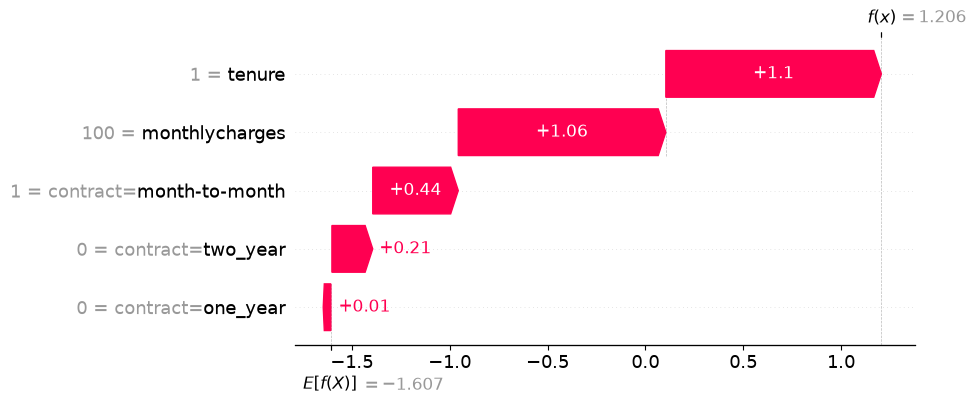

In [33]:
import shap

# same example customer used above
customer_churn = {
    "contract": "month-to-month",
    "monthlycharges": 100,
    "tenure": 1
}

# create SHAP explainer for the trained small logistic regression model
explainer = shap.LinearExplainer(
    model_small,
    X_train_small,
    feature_names=dv_small.get_feature_names_out()
)

# transform the customer using the already fitted DictVectorizer
customer_churn_X = dv_small.transform([customer_churn])

# explain this prediction
shap_values_customer = explainer(customer_churn_X)

# show feature contributions
shap.plots.waterfall(shap_values_customer[0])

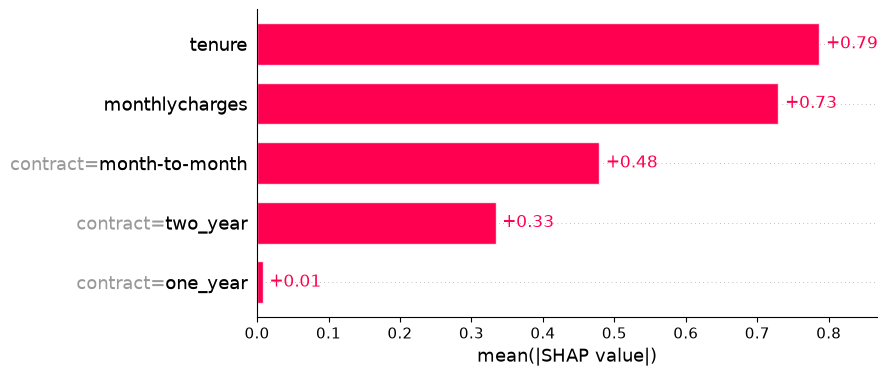

In [34]:
# explain all validation customers
shap_values = explainer(X_val_small)

# global feature importance
shap.plots.bar(shap_values)

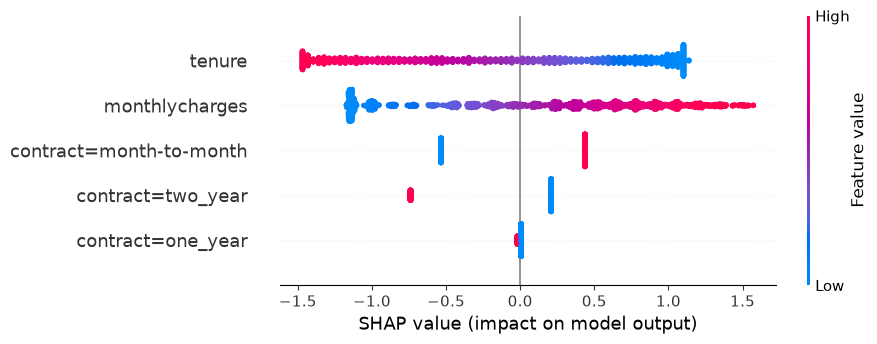

In [35]:
shap.plots.beeswarm(shap_values)

#### Logistic Regression Interpretation vs SHAP

Both methods tell a similar story:

* **Higher monthly charges** → increase churn tendency
* **Longer tenure** → decreases churn tendency
* **Month-to-month contract** → increases churn tendency
* **Two-year contract** → decreases churn tendency

The manual logistic regression analysis uses the learned **coefficients (weights)**. Their sign shows the direction of the effect, while each customer's contribution can be calculated as `feature value × weight`.

SHAP provides additional views:

* **Waterfall plot**
  **Question:** *Why did the model make this prediction for this customer?*
  Shows which features push one prediction toward churn or away from churn.

* **Bar plot**
  **Question:** *Which features matter most overall?*
  Shows global feature importance using the mean absolute SHAP value across many customers.

* **Beeswarm plot**
  **Question:** *Which features matter most, and in which direction do they affect churn?*
  Shows both global importance and whether high/low feature values push predictions toward or away from churn.

In this model, the SHAP analysis confirms the manual interpretation and shows that **tenure and monthly charges have the largest overall influence**, followed by contract type.

> **Manual coefficients:** explain how the logistic regression model works.
> **SHAP waterfall:** explains one prediction.
> **SHAP bar:** shows what matters most overall.
> **SHAP beeswarm:** shows what matters most and how feature values affect the prediction.

One limitation of comparing raw logistic regression coefficients is that **features may be on different scales**. For example, a one-hot encoded contract feature only changes between `0` and `1`, while `tenure` can range across many months and `monthlycharges` across many dollar values. Because of this, coefficient size alone is not a reliable way to decide which feature is most important overall. SHAP handles this more fairly by looking at how each feature changes predictions **relative to a background or average customer**. For linear models, the contribution is roughly based on:

```text
weight × (customer value - average value)
```

This means SHAP considers both the learned weight and how much the actual feature values vary in the data, which makes it more suitable for comparing overall feature importance.

### Part 11: Using the Model

After choosing and evaluating the model, retrain it using the **full training data** (`train + validation`) so it can learn from as much data as possible. Fit a new `DictVectorizer` together with the final model, then evaluate once on the untouched **test set**.

If test accuracy is close to validation accuracy, the model is likely generalizing reasonably well; a large gap may indicate overfitting.

For a single customer:

```python
X_customer = dv.transform([customer])
churn_probability = model.predict_proba(X_customer)[0, 1]
```

The returned value is the probability of `churn = 1`. With a threshold such as `0.5`, probabilities above the threshold are classified as churn. Use `transform()`, not `fit_transform()`, because new data must use the same encoding learned during training.

In [36]:
# create a dict vectorizer (do not use sparse matrices)
dv = DictVectorizer(sparse=False)

# fit full data to vectorizer and transform into one-hot-encoded (dict vectorizer does this only for categorical data)
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')
X_full_train = dv.fit_transform(dicts_full_train)
y_full_train = df_full_train.churn.values

# lbfgs is the default solver
# max_iter is increased because the default 100 iterations
# may not be enough for the model to converge
model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000 # needed to increase compared to the lecture
)

# fit trains the model from scratch
model.fit(X_full_train, y_full_train)

print(f"Bias / intercept (w_0): {model.intercept_[0]}")
print(f"Feature coefficients (w: weights) (rounded to 3 decimals):\n {model.coef_[0].round(3)}")
print(f"Number of training iterations: {model.n_iter_[0]}")

Bias / intercept (w_0): -0.1507621455783342
Feature coefficients (w: weights) (rounded to 3 decimals):
 [ 0.632 -0.009 -0.767 -0.04  -0.104  0.038 -0.116 -0.066 -0.057 -0.087
 -0.364  0.336 -0.116  0.002 -0.219  0.078 -0.004  0.085 -0.116 -0.113
  0.184 -0.116 -0.211 -0.235  0.091 -0.089 -0.056 -0.094 -0.12   0.204
 -0.134  0.078 -0.223  0.192 -0.122 -0.116  0.094 -0.069 -0.116  0.041
  0.169 -0.116 -0.197 -0.062  0.   ]
Number of training iterations: 865


In [37]:
# fit full data to vectorizer and transform into one-hot-encoded (dict vectorizer does this only for categorical data)
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)
# probability of churn = 1 (return only the column for likely to churn)
y_pred = model.predict_proba(X_test)[:, 1]

# classify customers as churn if predicted probability is at least 50%
churn_decision = (y_pred >= 0.5)

# calculate how often the predicted churn decision matches the actual value
accuracy = (y_test == churn_decision).mean()

print(f"Prediction accuracy: {accuracy:.3f}")
print(f"Percentage of correct predictions: {accuracy:.1%}")

Prediction accuracy: 0.810
Percentage of correct predictions: 81.0%


In [40]:
# select the last customer from the test set
customer = dicts_test[-1]

print("Customer data:")
for feature, value in customer.items():
    print(f"{feature:20s}: {value}")

# transform the customer using the fitted DictVectorizer
X_customer = dv.transform([customer])

# predict churn probability
churn_probability = model.predict_proba(X_customer)[0, 1]

# actual churn value from the test set
actual_churn = y_test[-1]

print(f"\nPredicted churn probability: {churn_probability:.2%}")
print(f"Predicted class: {'Churn' if churn_probability >= 0.5 else 'Not churn'}")
print(f"Actual class: {'Churn' if actual_churn == 1 else 'Not churn'}")

Customer data:
gender              : female
seniorcitizen       : 0
partner             : yes
dependents          : yes
phoneservice        : yes
multiplelines       : yes
internetservice     : fiber_optic
onlinesecurity      : yes
onlinebackup        : no
deviceprotection    : yes
techsupport         : no
streamingtv         : yes
streamingmovies     : yes
contract            : month-to-month
paperlessbilling    : yes
paymentmethod       : electronic_check
tenure              : 17
monthlycharges      : 104.2
totalcharges        : 1743.5

Predicted churn probability: 63.81%
Predicted class: Churn
Actual class: Churn
